# Visualize time series
## Line plot
### basic line plot

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

patent_org_type = pd.read_csv("data/time_series_three_gov_support_by_gender_collab_type_20250624.csv")

patent_org_type.head()

,patent_count_by_gender_collab,filing_year,gender_collab_type,gov_reliance_type_three_type,patent_count,pct
0,1303,1981,gender_collab,Indirect,126,9.669992
1,2486,2009,only_females,Direct,118,4.746581
2,2673,2008,only_females,Indirect,473,17.695473
3,1815,1984,gender_collab,No_support,1428,78.677686
4,1396,1989,only_females,Indirect,118,8.452722


Text(0.5, 0, 'Filing year')

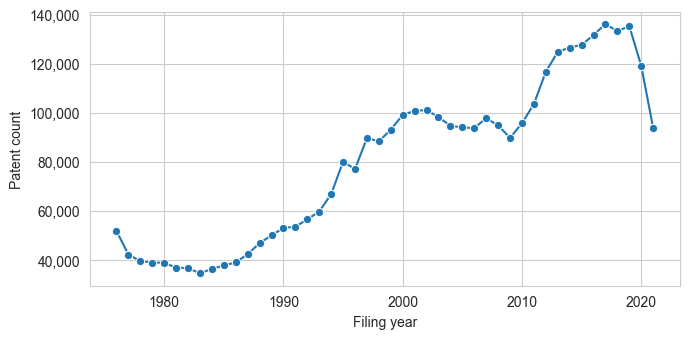

In [11]:
import matplotlib as mpl
# plot a basic line plot

fig, ax=plt.subplots(nrows=1, ncols=1, figsize=(7,3.5), tight_layout=True)

sns.lineplot(data=patent_org_type.groupby("filing_year", as_index=False)['patent_count'].sum(), x='filing_year', y='patent_count', marker="o",ax=ax)

ax.get_yaxis().set_major_formatter(mpl.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.ylabel("Patent count")
plt.xlabel("Filing year")

### Multiple line plot

Text(0.5, 0, 'Filing year')

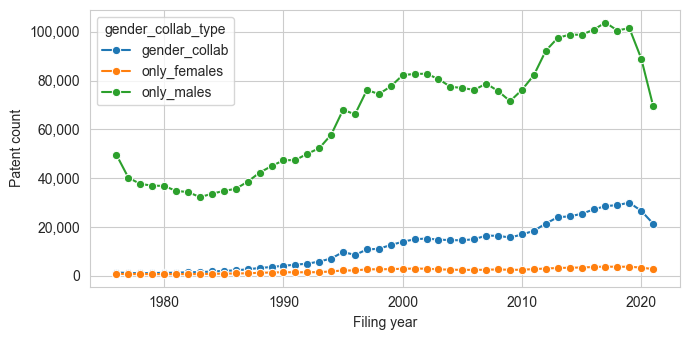

In [12]:
fig, ax=plt.subplots(nrows=1, ncols=1, figsize=(7,3.5), tight_layout=True)

sns.lineplot(data=patent_org_type.groupby(["filing_year",'gender_collab_type'], as_index=False)['patent_count'].sum(), x='filing_year', y='patent_count',
             hue='gender_collab_type',marker="o",ax=ax)

ax.get_yaxis().set_major_formatter(mpl.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.ylabel("Patent count")
plt.xlabel("Filing year")

### Stacked line plots
Let's visualize two time series: count and percent.

In [13]:
stack_line_plot_df = patent_org_type.groupby(by=["filing_year",'gender_collab_type'], as_index=False)['patent_count'].sum()

stack_line_plot_df['pct'] = stack_line_plot_df.groupby("filing_year")['patent_count'].transform(lambda x: x*100/x.sum())

stack_line_plot_df.head()

,filing_year,gender_collab_type,patent_count,pct
0,1976,gender_collab,1404,2.709745
1,1976,only_females,858,1.655955
2,1976,only_males,49551,95.634300
3,1977,gender_collab,1208,2.864460
4,1977,only_females,766,1.816371


<Axes: xlabel='filing_year', ylabel='pct'>

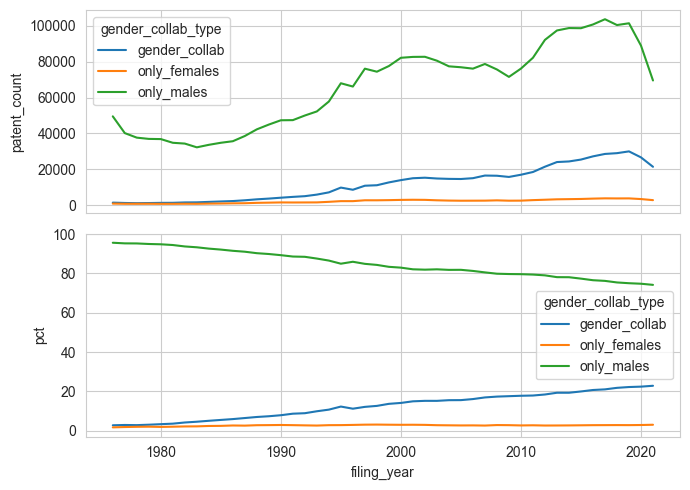

In [14]:
fig, axes=plt.subplots(nrows=2, ncols=1, figsize=(7,5), tight_layout=True, sharex=True)

sns.lineplot(data=stack_line_plot_df, x='filing_year', y='patent_count', hue='gender_collab_type',ax=axes.flat[0])

sns.lineplot(data=stack_line_plot_df, x='filing_year', y='pct', hue='gender_collab_type',ax=axes.flat[1])

## Area plot

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

patent_org_type = pd.read_csv("data/time_series_three_gov_support_by_gender_collab_type_20250624.csv")

patent_org_type.head()

,patent_count_by_gender_collab,filing_year,gender_collab_type,gov_reliance_type_three_type,patent_count,pct
0,1303,1981,gender_collab,Indirect,126,9.669992
1,2486,2009,only_females,Direct,118,4.746581
2,2673,2008,only_females,Indirect,473,17.695473
3,1815,1984,gender_collab,No_support,1428,78.677686
4,1396,1989,only_females,Indirect,118,8.452722


In [16]:
gov_reliance_type = patent_org_type.groupby(by=['filing_year','gov_reliance_type_three_type'], as_index=False)['patent_count'].sum()
gov_reliance_type['percent'] = gov_reliance_type.groupby("filing_year")['patent_count'].transform(lambda x: x*100/x.sum())

area_plot_df = pd.pivot_table(gov_reliance_type, values='percent', index='filing_year', columns='gov_reliance_type_three_type')

area_plot_df.head()

gov_reliance_type_three_type,Direct,Indirect,No_support
filing_year,,,
1976,3.601413,7.166155,89.232432
1977,4.173385,7.718391,88.108223
1978,4.343976,8.650003,87.006021
1979,4.268935,9.347452,86.383613
1980,4.462172,9.585692,85.952136


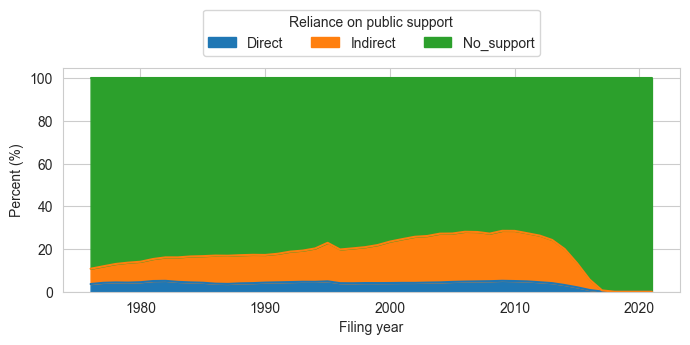

In [17]:
fig, ax=plt.subplots(nrows=1, ncols=1, figsize=(7,3.5), tight_layout=True, sharex=True)
g=area_plot_df.plot.area(ax=ax)
plt.xlabel("Filing year")
plt.ylabel("Percent (%)")

sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 1.29), ncol=3, title='Reliance on public support')

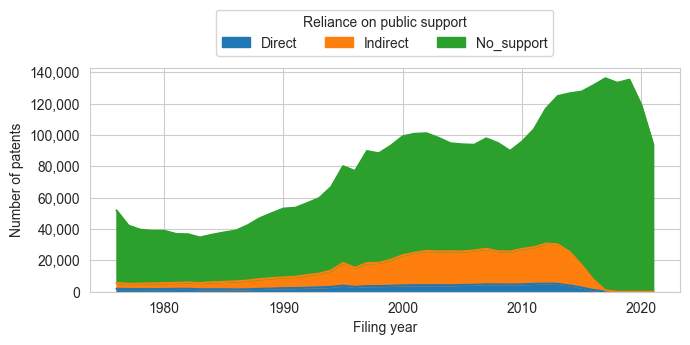

In [18]:
fig, ax=plt.subplots(nrows=1, ncols=1, figsize=(7,3.5), tight_layout=True, sharex=True)
g=pd.pivot_table(gov_reliance_type, values='patent_count', index='filing_year', columns='gov_reliance_type_three_type').plot.area(ax=ax)
plt.xlabel("Filing year")
plt.ylabel("Number of patents")

sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 1.29), ncol=3, title='Reliance on public support')

ax.get_yaxis().set_major_formatter(mpl.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))